# **NFL Draft Board: A Comprehensive Evaluation of What Makes Collegiate Football Players Successful in the NFL**

**Team**

Nathan Backman (natekbackman) (POC), Chris Marfisi (ChrisMarfisi), Hunter Geise (HunterGeise), Dylan Stafeil (DylanStafeil1), Brett Cerenzio (bjcerenz)


## **Overview**

The three-day NFL Draft is the one of the most critical days of the calendar year for NFL franchises because players selected can set up a team’s future for years to come or set them back for a long time. Many comparisons and eye-tests are used by front-offices and scouts to pick “their guy” in the draft, but every process has its flaws. In this project, we are predicting NFL career success of skill players (quarterbacks, running backs, wide receivers, and tight ends) in the upcoming draft by using collegiate data and former drafted players as reference points. In this new approach, we are using machine learning on the collegiate data to create a score that values player success, then run a clustering model to compare players in the draft class and previously drafted players. We find these two models as the most optimal for this problem because they are better at separating hype around players, letting the numbers do the talking. Our stakeholders in this project will be NFL front-offices and coaches, as well as any media outlets that make NFL Draft predictions. In the case of the front-offices and coaches, a successful project will help improve scouting departments and simplify draft-day decisions due to having an algorithm that shows which skill players can have the best careers. For media outlets, this impacts any analyst or personality that shares their mock drafts as the season comes to a close. This project would help solidify who the top players are, reducing noise in which players A and B will have better careers than players C and D.

## **Data**

We will are utilizing data from the [collegefootballdata.com](https://collegefootballdata.com/exporter/draft/picks) database & the [nflreadpy](https://github.com/nflverse/nflreadpy) package in Python. The collegefootballdata.com database which collects season level college football data going back to 2014 as well as draft information on each player. It collects advanced metrics such as average & total Predicted Points Added, which evaluates total number of points a player added to their offense, Usage Rate, which evaluates how often the player is utilized in the offense, & other basic box score statistics such as Passing Yards, Rushing Yards, TDs, etc. Variables are included in a glossary on the College Football Data webpage, and data is updated on a consistent basis to ensure up-to-date, accurate information. Nflreadpy will allow us to scrape draft data with player performance in the NFL, graded as [Weighted Approximate Value](https://www.pro-football-reference.com/about/approximate_value.htm), a measure created by pro-football-reference to evaluate & compare player performance across different positions with a single number. The ultimate goal is to join this draft data onto college football data’s draft data based on year, name, position, & pick number, which will then allow us to join on player id for the usage & predicted points added tables. Currently, a merged dataframe of usage and predicted points added statistics has over 27,000 rows & roughly 30 columns after filtering for D1 players. 

The first two code chunks consisted of reading in the data and determining how many nulls were in the complete data set.

In [1]:
%%capture
! pip install pandas matplotlib

In [2]:
import pandas as pd, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('../data/merged.csv', index_col = 0)


null_counts = merged.isnull().sum()
null_percentage = (merged.isnull().sum() / len(merged)) * 100

null_df = pd.DataFrame({
    'Column': null_counts.index,
    'Null_Count': null_counts.values,
    'Null_Percentage': null_percentage.values
})
final_null = null_df[null_df['Null_Count'] > 0].sort_values(by = "Null_Count", ascending = False)

pd.set_option('display.max_rows', None)
final_null


,Column,Null_Count,Null_Percentage
78,car_av,12408,100.000000
83,bench,12081,97.364603
86,cone,12078,97.340426
87,shuttle,12058,97.179239
85,broad_jump,11878,95.728562
82,forty,11864,95.615732
84,vertical,11857,95.559317
80,ht,11728,94.519665
81,wt,11727,94.511605
79,dr_av,11709,94.366538


After evaluating the nulls, we were able to see that many of the high null percentage variables had some sort of involvment with players who were drafted. Variables consisted of draft information such as team, pick, and round to events that players are evaluated on at the NFL Combine - bench (bench press), cone (three-cone drill), shuttle (shuttle run), broad_jump, forty (40-yard dash time), and vertical (vertical jump). In these instances, almost all of the players that attend the combine get drafted, which is a small percentage of the data, and at the same time not all drafted players attended the combine or competed in all events. Other nulls were position specific, such as passing_TD and passing_YDS for quarterbacks or rushing_YDS for runningbacks and some wide receivers if they ever had a carry. It is a rare occurance when you see a runningback, wide receiver, or tight end complete a pass. The same will go for quarterbacks recording a reception.



In the next few code chunks, we will start to get an idea of how the distribution of the data will shape up by looking at the overall data of skill position players (quarterbacks, runningbacks, wide receivers, and tight ends) alongside the skill players who were NFL draft picks. In our first plot, we are looking at the distribution of these skill position players.


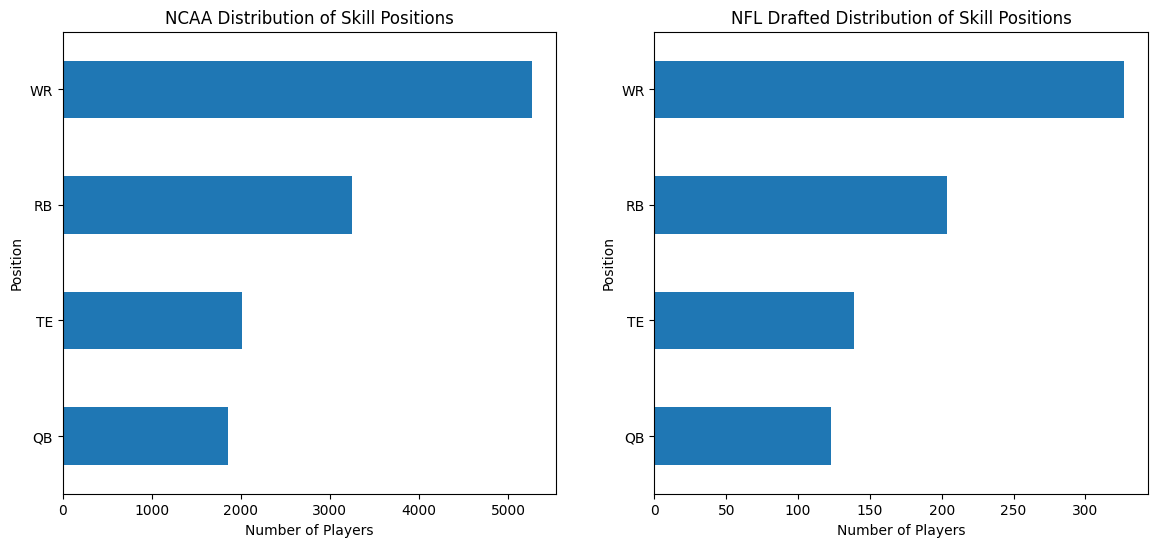

In [3]:
nfl = merged[merged['pick'].notnull()]

positions = merged['position_x'].value_counts().sort_values()
nfl_positions = nfl['position_x'].value_counts().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

positions.plot(kind = 'barh', ax = ax1)
ax1.set_title('NCAA Distribution of Skill Positions')
ax1.set_xlabel('Number of Players')
ax1.set_ylabel('Position')

nfl_positions.plot(kind = 'barh', ax = ax2)
ax2.set_title('NFL Drafted Distribution of Skill Positions')
ax2.set_xlabel('Number of Players')
ax2.set_ylabel('Position')
plt.show()


We see in both plots that the wide receiver position has the highest amount and quarterback has the lowest, which intuitively makes sense. In a given football game, a team will most likely have one quarterback, one or two runningbacks, two or three receivers, and one or two tight ends (each of these values are dependent on the formation the team is using). Therefore, some top teams will have multiple runningbacks, wide receivers, or tight ends selected within the same draft. Wide receivers happen to outnumber the other positions because historically, it is more likely that there are drafts where two or three wide receivers from the same school are drafted than two runningbacks or two tight ends. The same idea applies to quarterbacks, where only one quarterback will be on the field (unless there is a trick play or commitee). Therefore a school would only have one quarterback drafted.

Our next plot looks at the breakdown of total skill position players by conference.


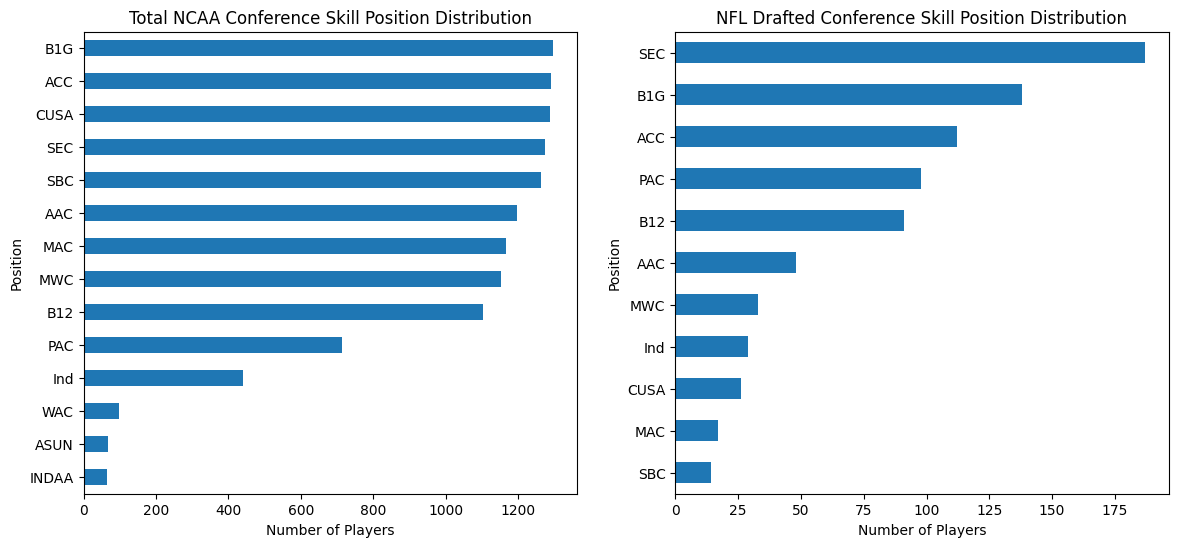

In [4]:
positions = merged['conference'].value_counts().sort_values()
nfl_positions = nfl['conference'].value_counts().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

positions.plot(kind = 'barh', ax = ax1)
ax1.set_title('Total NCAA Conference Skill Position Distribution')
ax1.set_xlabel('Number of Players')
ax1.set_ylabel('Position')

nfl_positions.plot(kind = 'barh', ax = ax2)
ax2.set_title('NFL Drafted Conference Skill Position Distribution')
ax2.set_xlabel('Number of Players')
ax2.set_ylabel('Position')
plt.show()


Here, we see a huge difference in the amount of skill position players by conference. These numbers are first heavily effected by how many teams are in a conference. More teams mean there will be more skill players used. Other factors like if a game is a blow out will influence how many skill players get in, where more bench players will see garbage time minutes they usually do not. Towards the top of the distribution, we see a mix of power conferences and smaller conference. Before conference realignment the SEC, Big 10, ACC, PAC-12, and Big 12 were known as the Power 5 because they had the most talent and would dominate all other conferences.

When looking at the drafted barplot, we see a huge discrepency in talent. The SEC, Big 10, ACC, PAC-12, and Big 12 are the top five teams. The SEC leads the way because "it means more in the South". In the timeframe of 2014-2025, you have Alabama, Georgia, LSU, and Florida be SEC powers that were towards the top of the rankings and produced large amounts of NFL skill players. All of the top high school recruits would commit to the top SEC schools because it was their best chance to make it to the pros. The Big 10 comes in behind with top skill producers like Ohio State, Michigan, and Penn State, producing NFL talent each year. Many think the Big 10 were the next best behind the SEC because of Ohio State being in the championship conversation every year and it had more depth than the other conferences. The ACC, PAC-12, and Big 12 round out the rest of the top five with schools like Clemson, Oregon, and Oklahoma carrying each of the respective conferences over this time frame. One other note is the Independents near the bottom, which is led by Notre Dame being a national powerhouse each year. Connecticut produces a few players but in this age there are less than five independent schools in Division 1 football.

Our next plot breaks down these conferences to see which schools produce the most NFL skill players.


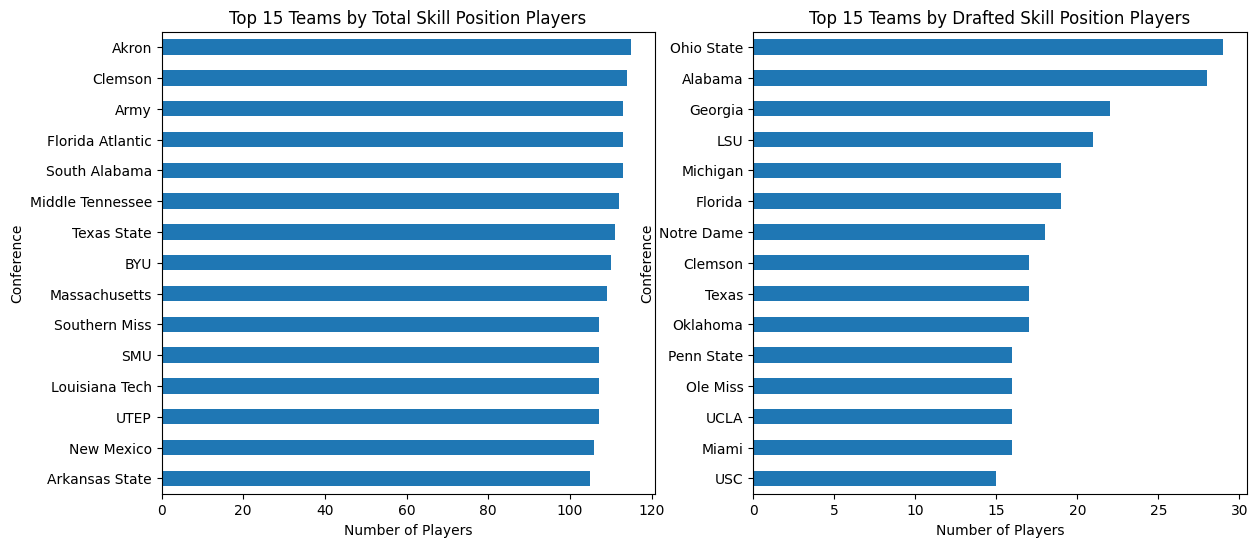

In [5]:
#top 15 teams by player count
positions = merged['team_x'].value_counts().head(15).sort_values()
nfl_positions = nfl['team_x'].value_counts().head(15).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

positions.plot(kind = 'barh', ax = ax1)
ax1.set_title('Top 15 Teams by Total Skill Position Players')
ax1.set_xlabel('Number of Players')
ax1.set_ylabel('Conference')

nfl_positions.plot(kind = 'barh', ax = ax2)
ax2.set_title('Top 15 Teams by Drafted Skill Position Players')
ax2.set_xlabel('Number of Players')
ax2.set_ylabel('Conference')
plt.show()


In this plot, we see the effects of how some of the smaller conferences managed to be near the top of the total players plot. Here, Clemson is the only power conference schools to show up in the top 15 by total players in a given year. During this time frame, Clemson was dominant. Like I had mentioned in the conference plot above, more blowout games lead to more playing time for skill position players who usually never see the field. 

When looking at the drafted plot, we see Ohio State and Alabama far ahead of the pack. These two schools are notorious for producing the best wide receiver prospects each year, as well as some top runningbacks. Going back to the last plot, we see Alabama (#2), Georgia (#3), LSU (#4), and Florida all represent the SEC in the top ten, the clear driving factor to their success. The one surprising school here is UCLA because they did not have a period of dominance unlike the rest of the school in this plot, whether it play in a top tier bowl game or make it to the College Football Playoff.


## **Preprocessing**

**This section is mainly focusing on the PCA aspects. Below, you can see the progress we made in narrowing down the most impactful variables to explain the variance in the project. We removed most of the variables that were index variables or simply descriptor variables like season or player_id, but kept every other predictor to evaluate it's signficance.**

In [6]:
%%capture
! pip install pandas numpy scikit-learn matplotlib

In [7]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Here, we just imported the data we needed and then removed unnecessary columns as I stated above. This section is mainly the prep for the PCA.

In [8]:
#importing data, only selecting numeric columns with less than 50% of the data missing

df = pd.read_csv('/workspaces/group-project-big-brains-and-nathan/data/merged.csv', index_col=0)

numeric_df = df.select_dtypes(include='number')

#print(numeric_df.columns)

drop_columns = ['player_id', 'season_x', 'college_id', 'nfl_team_id',
                'year', 'round_x', 'pick_number', 'overall', 'height_in', 'weight_lbs',
                'season_y', 'round_y', 'pick', 'w_av', 'car_av', 'dr_av', 'wt', 'rookie_season',
                'last_season', 'birth_year']

# dropping unnecessary columns
numeric_df = numeric_df.drop(columns=drop_columns)

# filling in NAs for counting stats (they should all be zero)
numeric_df.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)
# dropping columns with more than 50% of the data missing
numeric_df = numeric_df.loc[:, numeric_df.isnull().mean() < 0.5]

numeric_df.shape

(12408, 43)

This is just the first section of PCA, we'll be doing another using imptuation.

In [9]:
#dropping the rows with NA still, i'll be doing another round of PCA using imputation
numeric_df_1 = numeric_df.copy()

numeric_df_1 = numeric_df_1.dropna()

print(numeric_df_1.shape)
print(list(numeric_df_1.columns))

(6256, 43)
['usage_passing_downs', 'usage_standard_downs', 'usage_third_down', 'usage_second_down', 'usage_first_down', 'usage_rush', 'usage_var_pass', 'usage_overall', 'avg_ppa_passing_downs', 'avg_ppa_standard_downs', 'avg_ppa_third_down', 'avg_ppa_second_down', 'avg_ppa_first_down', 'avg_ppa_var_pass', 'avg_ppa_all', 'total_ppa_passing_downs', 'total_ppa_standard_downs', 'total_ppa_third_down', 'total_ppa_second_down', 'total_ppa_first_down', 'total_ppa_rush', 'total_ppa_var_pass', 'total_ppa_all', 'fumbles_FUM', 'fumbles_LOST', 'fumbles_REC', 'passing_ATT', 'passing_COMPLETIONS', 'passing_INT', 'passing_PCT', 'passing_TD', 'passing_YDS', 'passing_YPA', 'receiving_LONG', 'receiving_REC', 'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_LONG', 'rushing_TD', 'rushing_YDS', 'rushing_YPC']


In [10]:
#scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df_1)

pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

**In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**

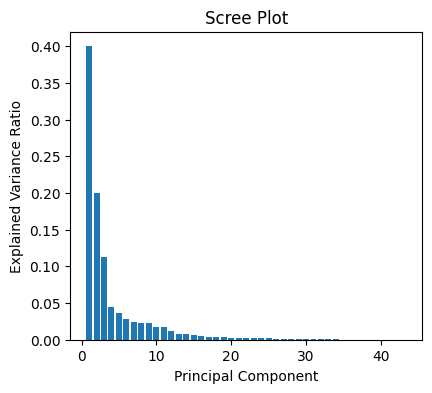

In [11]:
#scree plot
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

This plot helps us see where the falloff on variable importance and impact happens. At about 10 variables we hit the 90% explanation point, which is a generally strong spot to cut off to not overfit. 

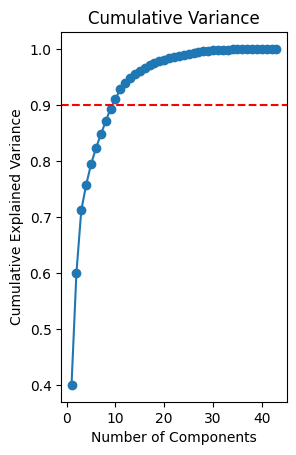

In [12]:
#cumulative variance explained plot, with a benchmark at 90%

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance')
plt.show()

In [13]:
#pca to decide how many components we want
n_components_90 = np.argmax(cumulative >= 0.90) + 1
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X_scaled)

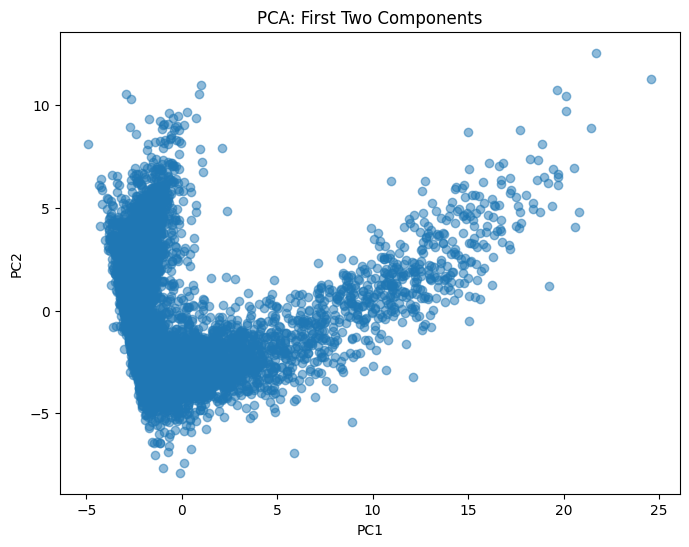

In [14]:
#comparing the first two components

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First Two Components')
plt.show()

**Above we see that there are two distinct directions that players begin to skew to. One direction is up and do the right, the other is just up. What this kind of shows is that the data isn't so easily described by distinct, rigid clusters as we are trying to do in our analysis.**

In [15]:
%%capture
#Just wanted to see that outlier on the top right
outlier_idx = np.argmax(X_pca[:, 0])
print(numeric_df.iloc[outlier_idx])
print(df.loc[numeric_df.index[outlier_idx], 'name_x'])

In [16]:
#printing out the top 10 features that explain the variance
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=numeric_df_1.columns,
    columns=[f'PC{i+1}' for i in range(n_components_90)]
)

print(loadings['PC1'].abs().sort_values(ascending=False).head(10))

usage_overall           0.230361
usage_second_down       0.228545
usage_passing_downs     0.225403
usage_third_down        0.224184
usage_standard_downs    0.223494
usage_first_down        0.222031
passing_ATT             0.221440
passing_YDS             0.221403
passing_COMPLETIONS     0.220701
passing_TD              0.215737
Name: PC1, dtype: float64


**Going through the process again, but this time using imputation instead.**

In [17]:

from sklearn.impute import SimpleImputer

In [18]:
numeric_df_2 = numeric_df.copy()

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(numeric_df_2)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

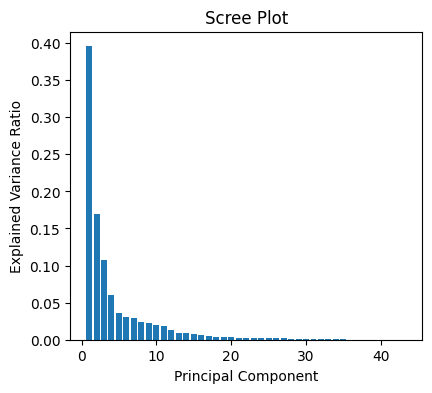

In [19]:
#scree plot
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

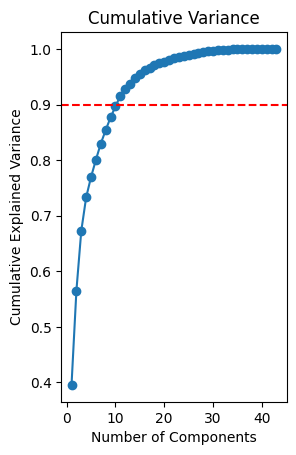

In [20]:
#cumulative variance explained plot, with a benchmark at 90%

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance')
plt.show()

#this time the variance is explained at slightly more components, with 10 just hitting under the threshold

In [21]:
#pca to decide how many components we want
n_components_90 = np.argmax(cumulative >= 0.90) + 1
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X_scaled)

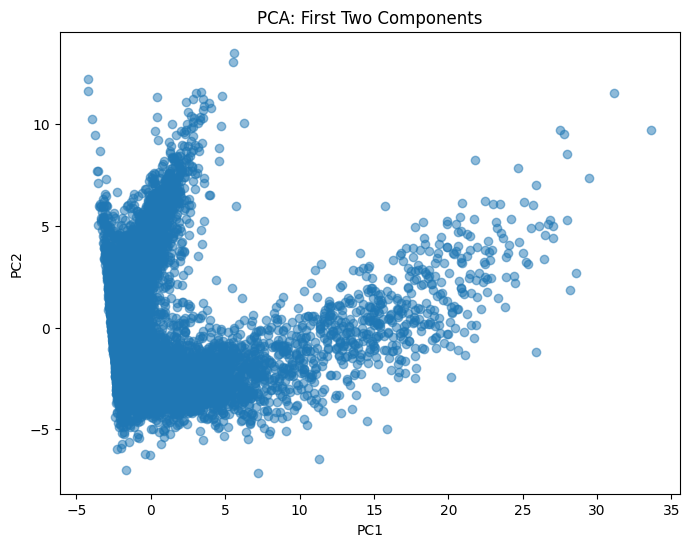

In [22]:
#comparing the first two components

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First Two Components')
plt.show()

#here we have a much more distinct two peak situation, with the sideways peak and the up-right peak
#looking more clear

In [23]:
#printing out the top 10 features that explain the variance
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=numeric_df_2.columns,
    columns=[f'PC{i+1}' for i in range(n_components_90)]
)

print(loadings['PC1'].abs().sort_values(ascending=False).head(10))

usage_overall           0.229869
usage_second_down       0.226902
usage_passing_downs     0.224656
usage_standard_downs    0.222901
usage_third_down        0.222636
usage_first_down        0.221576
passing_YDS             0.217355
passing_ATT             0.216832
passing_COMPLETIONS     0.216369
total_ppa_third_down    0.214545
Name: PC1, dtype: float64


**Now we'll be using KNN, K-Nearest-Neighbors Imputation to analyze this data. Just a different type of imputation.**

In [24]:
from sklearn.impute import KNNImputer
#redoing the analysis but using the imputer strategy, still removing columns with too many NAs

numeric_df_nn = numeric_df.copy()

imputer = KNNImputer()
X_imputed = imputer.fit_transform(numeric_df_nn)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

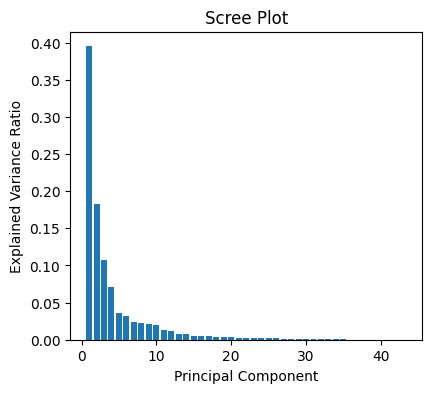

In [25]:
#scree plot
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

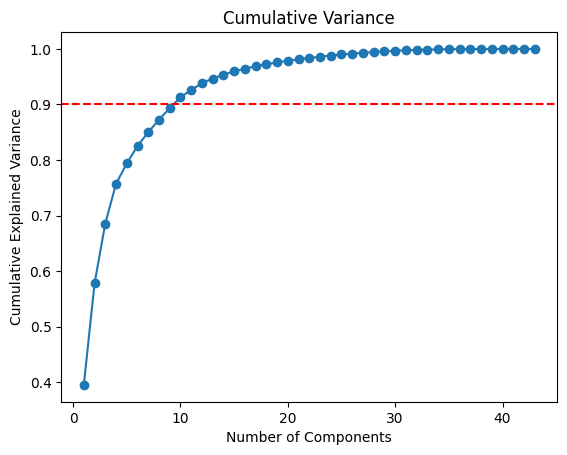

In [26]:
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance')
plt.show()

You can see a relatively strong performance above, with 10 components explaining over 90% of the variation in the dataset. 

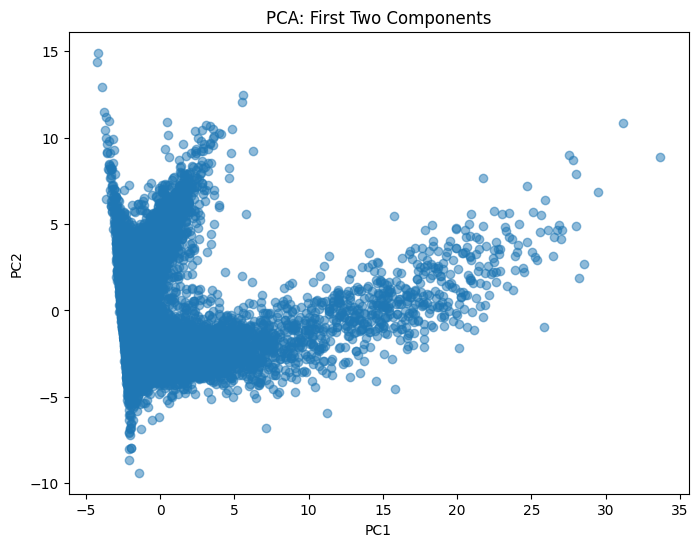

In [27]:
n_components_90 = np.argmax(cumulative >= 0.90) + 1
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First Two Components')
plt.show()

Here there arrives a third peak. Now the data has become separated into 3 distinct directions, with a small peak of direct PC2 increase to basically no PC1 increase.

In [28]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=numeric_df_2.columns,
    columns=[f'PC{i+1}' for i in range(n_components_90)]
)

print(loadings['PC1'].abs().sort_values(ascending=False).head(10))

usage_overall           0.229854
usage_second_down       0.226873
usage_passing_downs     0.224647
usage_standard_downs    0.222884
usage_third_down        0.222643
usage_first_down        0.221563
passing_YDS             0.217514
passing_ATT             0.216958
passing_COMPLETIONS     0.216512
total_ppa_third_down    0.214895
Name: PC1, dtype: float64


**We'll be incorporating UMAP here, using it in combination with KNN to see a 3D visualization of what this data looks like after the PCA.**

In [29]:
%%capture
! pip install umap-learn

In [30]:
from umap import UMAP

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
numeric_df_umap = numeric_df.copy()

imputer = KNNImputer()
X_imputed = imputer.fit_transform(numeric_df_umap)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

umap = UMAP(n_components=3)
umap.fit(X_scaled)

,n_neighbors,15
,n_components,3
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


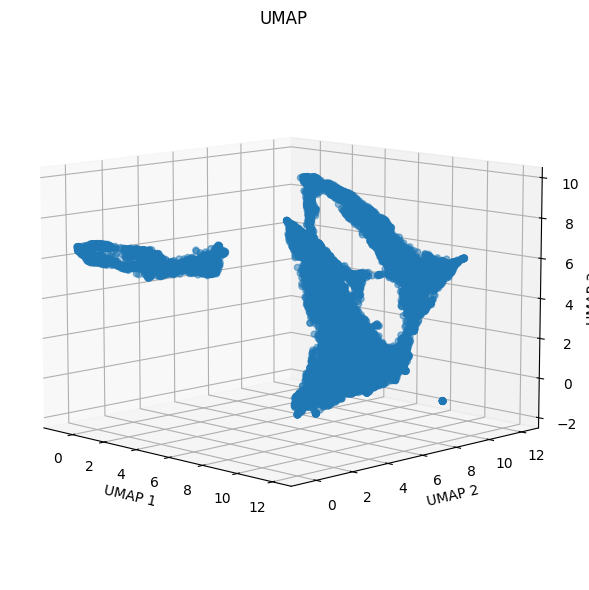

In [32]:
from mpl_toolkits.mplot3d import Axes3D
X_umap = umap.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(111, projection = '3d')

ax.view_init(elev = 10, azim = -45)

ax.scatter3D(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], alpha=0.5)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel("UMAP 3", labelpad = 1)
ax.set_title('UMAP')
plt.tight_layout()
plt.show()

Above you can see the distinct clusters that we're looking for, with that lone group on the top left of the visualization and those two similar but distinct groups in the center right.  The groups in the center right are not as easy to distinguish because they share a simmilar base, more like two versions of a similar group, but we'll try to capture this in our analysis.

**We'll now be testing plotly and using that for visualization to give a different lens than UMAP.**

In [33]:
%%capture
! pip install plotly

In [34]:
import plotly.express as px

X_umap = umap.fit_transform(X_scaled)

df_umap = pd.DataFrame({
    "UMAP 1": X_umap[:, 0],
    "UMAP 2": X_umap[:, 1],
    "UMAP 3": X_umap[:, 2]
})

fig = px.scatter_3d(
    df_umap,
    x="UMAP 1",
    y="UMAP 2",
    z="UMAP 3",
    opacity=0.5,
    title="UMAP"
)

fig.update_layout(
    scene=dict(
        xaxis_title="UMAP 1",
        yaxis_title="UMAP 2",
        zaxis_title="UMAP 3",
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=0.5)  # roughly similar to elev=10, azim=-45
        )
    )
)

fig.show()

In [35]:
df_umap = pd.DataFrame({
    "PCA 1": X_pca[:, 0],
    "PCA 2": X_pca[:, 1],
    "PCA 3": X_pca[:, 2]
})

fig = px.scatter_3d(
    df_umap,
    x="PCA 1",
    y="PCA 2",
    z="PCA 3",
    opacity=0.5,
    title="PCA"
)

fig.update_layout(
    scene=dict(
        xaxis_title="PCA 1",
        yaxis_title="PCA 2",
        zaxis_title="PCA 3",
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=0.5)  # roughly similar to elev=10, azim=-45
        )
    )
)

fig.show()

The second graph doesn't distinguish the data in the way that UMAP did, unable to identify the distinct differences in the way that UMAP's interactive visuals could. It's valuable to see what it could visualize, but it doesn't complete our objective.  

## **Modeling**

**We Did some initial modeling with Catboost, Random Forest, & XGBoost on our raw, untransformed variables to get some initial baseline scores for our model. Once we're able to cluster the players effectively to identify similar attributes between players and finalize our dimensionality reduction, these will be used in the final model.**

In [36]:
%%capture
# installing catboost
! pip install catboost

Reading in the Data

In [37]:
%%capture
import pandas as pd, numpy as np, \
seaborn as sns, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('../data/merged.csv', index_col = 0)
merged.head()

This next block of code is filling in NA values with 0, since the data source we read it from doesn't account for 0 stats. Because of this, any stat that's not assigned to a player is effectively 0. This also removes all players that weren't drafted and any players with NA height & weight values. This left us with 790 players in our dataset. We also transformed our y variable (w_av) from a cumulative stat to a rate stat. This is necessary since players who play longer will naturally have higher w_av even though they aren't necessarily better. 

In [38]:
# filling in NAs for counting stats (they should all be zero)
merged.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)

merged.dropna(axis = 0, subset = 'overall', inplace=True)

merged['INT_pct'] = merged['passing_INT']/merged['passing_ATT']

merged.fillna(value={'INT_pct' : 0}, inplace=True)

# Taking yearly average of wAV so players drafted earlier don't have higher values
# since wAV is a cumulative stat
# (in other words, I'm turning it into a rate stat)
merged['adjusted_w_av'] = (merged['w_av']/
 ((merged['last_season'] + 1) - merged['year'])
)

X = merged[['position_x', 'usage_overall', 'avg_ppa_all', 'total_ppa_all','conference',
            'fumbles_FUM', 'fumbles_LOST', 'passing_ATT', 'passing_COMPLETIONS',
            'passing_PCT', 'INT_pct','passing_TD', 'passing_YDS','passing_YPA', 'receiving_REC',
            'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_TD',
            'rushing_YDS', 'rushing_YPC', 'age', 'height', 'weight']]

y = merged['adjusted_w_av'].fillna(value=0)

# Finding NA values in X. Should only be NA values in height & weight.
na_idx = X[X.isna().any(axis=1)].index
print("NA Indexes:", na_idx)

X_nona = X.drop(index=na_idx, inplace = False)
y_nona = y.drop(index=na_idx, inplace=False)

y_nona.shape

NA Indexes: Index([114, 229, 4314, 7510], dtype='int64')


(790,)

In the plots below we can see the distributions of our Y variable both before & after a log transformation. Currently, our y variable is severely right skewed. While a log transformation doesn't completely solve the problem, it does make it look a little more normal.

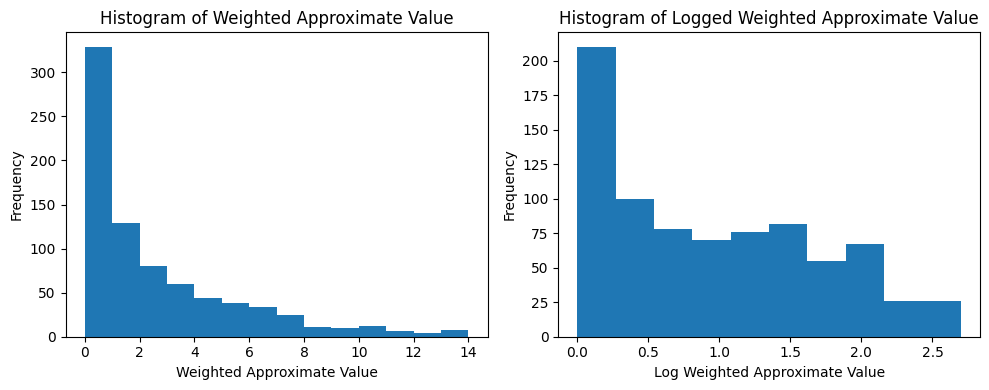

In [39]:
bin_width = 1

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

fig, ax = plt.subplots(1, 2, figsize = (10,4))

ax1 = ax[0]
ax2 = ax[1]

ax1.hist(y_nona, bins = bins)
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Weighted Approximate Value')
ax1.set_title('Histogram of Weighted Approximate Value')

y_log = y_nona.copy()
y_log = np.log(y_log + 1)

bin_width = np.log(2)

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

ax2.hist(y_log)
ax2.set_ylabel('Frequency')
ax2.set_xlabel('Log Weighted Approximate Value')
ax2.set_title('Histogram of Logged Weighted Approximate Value')
plt.tight_layout()
plt.show()

This code helps prepare the data for the Catboost Model. The Catboost model allows us to keep the categorical variables without OneHotEncoding, so we leave them as they are.

In [40]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X_nona, y_log, test_size = 0.3)

num_cols = train_x.select_dtypes(include=np.number).columns
cat_cols = train_x.select_dtypes(include=['object', 'str']).columns


# Create transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

# Fit on training data, transform both
train_x = preprocessor.fit_transform(train_x)
test_x = preprocessor.transform(test_x)

This code runs the catboost model, using RMSE as the loss funciton. Here we can see some significant overfitting occuring, as the test RMSE doesn't change after the first 170 iterations while the train data error decreases significantly.

In [41]:
from catboost import CatBoostRegressor

# finds categorical features
cat_features = train_x.select_dtypes(include=['object', 'category', 'str']).columns
cat_indices = [train_x.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    l2_leaf_reg = 10,
    verbose=100,
    random_seed=101
)

model.fit(
    train_x,
    train_y,
    eval_set = (test_x, test_y),
    cat_features=cat_indices # assigns categorical features
)

preds = model.predict(test_x)

0:	learn: 0.7571241	test: 0.7914257	best: 0.7914257 (0)	total: 53.3ms	remaining: 1m 46s
100:	learn: 0.6101726	test: 0.7342329	best: 0.7342329 (100)	total: 455ms	remaining: 8.55s
200:	learn: 0.5419544	test: 0.7237638	best: 0.7218276 (183)	total: 901ms	remaining: 8.07s
300:	learn: 0.4870779	test: 0.7217156	best: 0.7215868 (297)	total: 1.26s	remaining: 7.11s
400:	learn: 0.4432488	test: 0.7206201	best: 0.7201380 (353)	total: 1.65s	remaining: 6.58s
500:	learn: 0.4058773	test: 0.7207478	best: 0.7201380 (353)	total: 1.98s	remaining: 5.92s
600:	learn: 0.3697579	test: 0.7225477	best: 0.7201380 (353)	total: 2.29s	remaining: 5.33s
700:	learn: 0.3405475	test: 0.7242681	best: 0.7201380 (353)	total: 2.65s	remaining: 4.92s
800:	learn: 0.3127879	test: 0.7258970	best: 0.7201380 (353)	total: 3.02s	remaining: 4.52s
900:	learn: 0.2930240	test: 0.7268967	best: 0.7201380 (353)	total: 3.38s	remaining: 4.13s
1000:	learn: 0.2728676	test: 0.7301901	best: 0.7201380 (353)	total: 3.7s	remaining: 3.7s
1100:	learn: 

After transforming the predictions back to their actual scale, we get an RMSE of 3.05.

In [42]:
from sklearn.metrics import root_mean_squared_error as rmse
preds_exp = np.exp(preds) - 1
test_y_exp = np.exp(test_y) - 1

test_rmse = rmse(test_y_exp, preds_exp)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 3.05


Looking at this histogram comparing the predicted values & the actual values, it seems the predictions don't predict high enough.

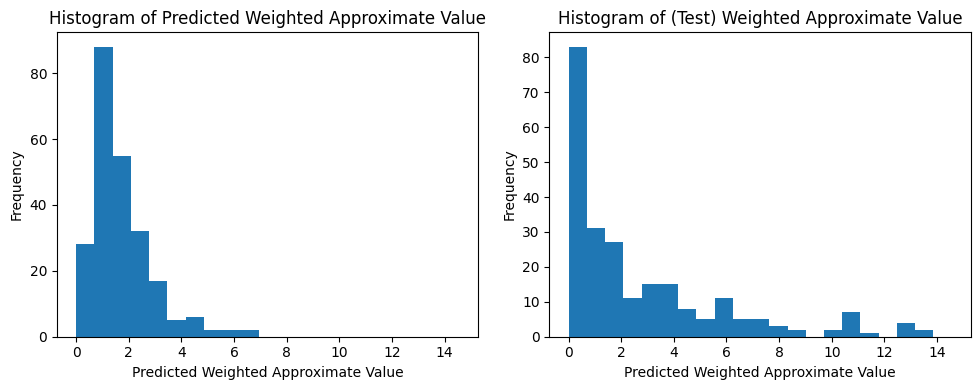

In [43]:
fig, ax = plt.subplots(1,2,figsize = (10,4))

ax1 = ax[0]
ax2 = ax[1]

ax1.hist(preds_exp, bins = bins)
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Predicted Weighted Approximate Value')
ax1.set_title('Histogram of Predicted Weighted Approximate Value')

ax2.hist(test_y_exp, bins = bins)
ax2.set_ylabel('Frequency')
ax2.set_xlabel('Predicted Weighted Approximate Value')
ax2.set_title('Histogram of (Test) Weighted Approximate Value')

plt.tight_layout()
plt.show()

This code below performs 10-fold cross-validation with CatBoost. This gives us an RMSE of 2.67.

In [44]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include=['object', 'str']).columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original) # Apply StandardScaler to numerical columns
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category', 'str']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = CatBoostRegressor(
        iterations=2000,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=1000,
        l2_leaf_reg = 10,
        random_seed=101 # Added random_seed for reproducibility
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = (X_val_processed, y_val_fold),
        cat_features=cat_indices_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

0:	learn: 0.7615862	test: 0.8176041	best: 0.8176041 (0)	total: 3.76ms	remaining: 7.51s
1000:	learn: 0.3062265	test: 0.7367422	best: 0.7231914 (173)	total: 4.25s	remaining: 4.24s
1999:	learn: 0.1839003	test: 0.7409859	best: 0.7231914 (173)	total: 8.56s	remaining: 0us

bestTest = 0.7231913745
bestIteration = 173

Shrink model to first 174 iterations.
0:	learn: 0.7641433	test: 0.8024851	best: 0.8024851 (0)	total: 3.53ms	remaining: 7.06s
1000:	learn: 0.3133638	test: 0.7354668	best: 0.7345717 (790)	total: 4.09s	remaining: 4.08s
1999:	learn: 0.1841648	test: 0.7317029	best: 0.7314573 (1794)	total: 8.4s	remaining: 0us

bestTest = 0.7314572866
bestIteration = 1794

Shrink model to first 1795 iterations.
0:	learn: 0.7684157	test: 0.7630714	best: 0.7630714 (0)	total: 4.98ms	remaining: 9.95s
1000:	learn: 0.3174315	test: 0.6941698	best: 0.6836515 (203)	total: 4.03s	remaining: 4.02s
1999:	learn: 0.1761649	test: 0.7067326	best: 0.6836515 (203)	total: 8.21s	remaining: 0us

bestTest = 0.6836514752
best

This code runs the same code as above except now it's using a RandomForestRegressor instead of CatBoost. This gives us a RMSE of 2.75. 

In [45]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include=['object', 'str']).columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    model = RandomForestRegressor(
        n_estimators = 1000,
        max_features = 'sqrt'
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

CV RMSE: 2.75


Finally, we do the same thing with XGBoost. This gives us an RMSE of 2.75.

In [46]:
%%capture
! pip install xgboost

In [47]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []


num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include=['object', 'str']).columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Creates a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    model = XGBRegressor(
        n_estimators = 1000,
        objective = 'reg:squarederror',
        learning_rate = 0.05,
        max_depth = 6,
        random_state = 101,
        reg_lambda = 5,
        eval_metric = 'rmse'
    )

    print(f"{"="*30}New Fold{"="*30}")

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = [(X_val_processed, y_val_fold)],
        verbose = 1000
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

==============================New Fold==============================
[0]	validation_0-rmse:0.81638
[999]	validation_0-rmse:0.76985
==============================New Fold==============================
[0]	validation_0-rmse:0.80013
[999]	validation_0-rmse:0.78804
==============================New Fold==============================
[0]	validation_0-rmse:0.75967
[999]	validation_0-rmse:0.75287
==============================New Fold==============================
[0]	validation_0-rmse:0.72359
[999]	validation_0-rmse:0.72237
==============================New Fold==============================
[0]	validation_0-rmse:0.74848
[999]	validation_0-rmse:0.70161
==============================New Fold==============================
[0]	validation_0-rmse:0.72682
[999]	validation_0-rmse:0.67907
==============================New Fold==============================
[0]	validation_0-rmse:0.82438
[999]	validation_0-rmse:0.75349
==============================New Fold==============================
[0]	validation

**We're also looking to add Instance-Based Uncertainty Estimation (IBUG) to our final model to create a probabilistic distribution of estimates rather than just a single point estimate.**

## **Problems & Challenges**

## **Next Steps**

Our next step is to finalize the PCA and clustering and add them to our model. We hope to get this done by the 22nd of March, that way we will have time to finalize our models and tune parameters. We want to get all of our modeling done by April 5, so we have plenty of time to write the final report and create a presentation.